In [3]:
#Insurance charge prediction
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score


In [4]:
data=pd.read_csv("C:/Users/allad/Downloads/insurance.csv")
#data cleaning and analysis
print(data.shape)
print(data.head(15))
print('finding null values',data.isnull().sum())
print('finding duplicates',data.duplicated().sum())
dat=data.drop_duplicates()
print('after removing duplicates',dat.duplicated().sum())

(1338, 7)
    age     sex     bmi  children smoker     region      charges
0    19  female  27.900         0    yes  southwest  16884.92400
1    18    male  33.770         1     no  southeast   1725.55230
2    28    male  33.000         3     no  southeast   4449.46200
3    33    male  22.705         0     no  northwest  21984.47061
4    32    male  28.880         0     no  northwest   3866.85520
5    31  female  25.740         0     no  southeast   3756.62160
6    46  female  33.440         1     no  southeast   8240.58960
7    37  female  27.740         3     no  northwest   7281.50560
8    37    male  29.830         2     no  northeast   6406.41070
9    60  female  25.840         0     no  northwest  28923.13692
10   25    male  26.220         0     no  northeast   2721.32080
11   62  female  26.290         0    yes  southeast  27808.72510
12   23    male  34.400         0     no  southwest   1826.84300
13   56  female  39.820         0     no  southeast  11090.71780
14   27    male

In [14]:
#data splitting
dt=dat.drop(columns=['charges'])
X=pd.get_dummies(dt,columns=['sex','smoker','region'],drop_first=True)
y=dat['charges']
x_train,x_test,y_train,y_test,=train_test_split(X,y,test_size=0.2,random_state=42)
print(X.head())

   age     bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0     False        True             False   
1   18  33.770         1      True       False             False   
2   28  33.000         3      True       False             False   
3   33  22.705         0      True       False              True   
4   32  28.880         0      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


In [15]:
#Model creation
model=LinearRegression()
#model training
model.fit(x_train,y_train)
#make predictions
y_pred=model.predict(x_test)
#calculate errors
mae=mean_absolute_error(y_test,y_pred)
r2score=r2_score(y_test,y_pred)
print('Mean absolute Error:',mae)
print('R2 score:',r2score)
res=pd.DataFrame({'Actual':y_test,
                 'Predicted':y_pred})
print(res.head(10))


Mean absolute Error: 4177.045561036318
R2 score: 0.8069287081198012
           Actual     Predicted
900    8688.85885   8143.693884
1064   5708.86700   5737.115683
1256  11436.73815  14369.314876
298   38746.35510  31745.513636
237    4463.20510   8962.386657
481    9304.70190  13149.722353
240   38511.62830  30446.760679
277    2150.46900   1453.288813
415    7345.72660  10633.018402
707   10264.44210  11318.943794


In [23]:
new=pd.DataFrame({'age':[27],
                  'bmi':[36.4],
                  'children':[1],
                  'sex_male':[1],
                  'smoker_yes':[0],
                  'region_northwest':[1],
                  'region_southeast':[0],
                  'region_southwest':[0] })
print('New data\n',new)
res=model.predict(new)
print('Predicted chrages for new data\n',res)

New data
    age   bmi  children  sex_male  smoker_yes  region_northwest  \
0   27  36.4         1         1           0                 1   

   region_southeast  region_southwest  
0                 0                 0  
Predicted chrages for new data
 [7249.47608081]


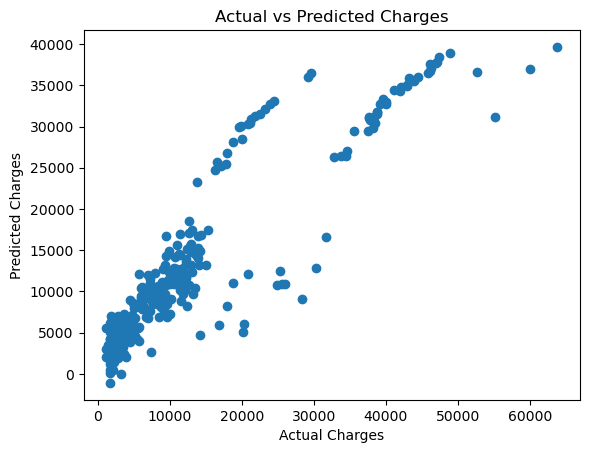

In [21]:
#visualization
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()